
# Probing LLaMA for Gradient-Descent-Like In‑Context Learning (ICL)

This notebook reproduces the core evaluation ideas of **"Transformers Learn In-Context by Gradient Descent"** (ICML 2023) — but instead of training small Transformers from scratch, we test whether a pre-trained LLaMA-style model performs gradient-descent-like in-context learning on synthetic regression tasks.



## 0. Environment

In [16]:

# If running in a fresh environment, uncomment this cell.
# %pip install -q transformers accelerate einops torch torchvision torchaudio



import os, math, re, json, random, time
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any, Optional

os.environ["TRANSFORMERS_NO_TF"] = "1"      # prevents HF Transformers from importing TensorFlow backend
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"    # hide TF logs if it still gets imported somehow
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # cleaner logs

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

import matplotlib.pyplot as plt
from statistics import mean

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = os.environ.get("LLAMA_MODEL", "TinyLlama/TinyLlama-1.1B-Chat-v1.0")
print("Using device:", device)
print("MODEL_NAME:", MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
)
model.to(device)
model.eval();


Using device: cuda
MODEL_NAME: TinyLlama/TinyLlama-1.1B-Chat-v1.0



## 1. Task generators and baselines
We follow the paper's setup: draw a random linear teacher `W` and sample inputs `x ~ U(-α, α)`. Then `y = W x` (no noise for simplicity).

We compute:
- GD-1: One step of gradient descent on the MSE loss starting from `W0 = 0`.
- GD++: A simple curvature-heuristic variant using a Gram-matrix preconditioning.


In [18]:
D_DEFAULT = 20  # change this once and reuse
SEED = 42       # set None for nondeterministic sampling

rng_global = np.random.default_rng(SEED)

@dataclass
class LinearTask:
    W: np.ndarray         # shape: (1, d)
    X: np.ndarray         # shape: (N, d)
    y: np.ndarray         # shape: (N,)
    x_test: np.ndarray    # shape: (d,)
    y_test: float         # scalar

def sample_linear_task(
    d: int = D_DEFAULT,
    N: Optional[int] = None,
    alpha: float = 1.0,
    rng: Optional[np.random.Generator] = None,
) -> LinearTask:
    """
    Sample a noiseless linear regression task:
        y = W x,  x ~ U(-alpha, alpha)^d
    Defaults to N = 2d + 1 in-context examples to match the paper.
    """
    if rng is None:
        rng = rng_global
    if N is None:
        N = 2 * d + 1

    # Teacher
    W = rng.standard_normal(size=(1, d))        # shape (1, d)

    # Context inputs and targets
    X = rng.uniform(-alpha, alpha, size=(N, d)) # (N, d)
    y = (W @ X.T).reshape(-1)                   # (N,)

    # Query
    x_test = rng.uniform(-alpha, alpha, size=(d,))
    y_test = float(W @ x_test)

    return LinearTask(W=W, X=X, y=y, x_test=x_test, y_test=y_test)

def gd1_predict(X: np.ndarray, y: np.ndarray, x_test: np.ndarray, eta: float = 1.0) -> float:
    """
    One GD step on MSE with W0 = 0:
        W1 = (eta/N) sum_i y_i x_i^T
        y_hat = W1 x_test = (eta/N) sum_i y_i <x_i, x_test>
    """
    N = X.shape[0]
    return float((eta / N) * np.sum(y * (X @ x_test)))

def gdpp_predict(
    X: np.ndarray,
    y: np.ndarray,
    x_test: np.ndarray,
    eta: float = 1.0,
    gamma: float = 0.0
) -> float:
    """
    Simple GD++-style preconditioning via Gram matrix G = X X^T:
        w = (I - gamma * G) y
        y_hat = (eta/N) sum_i w_i <x_i, x_test>
    """
    N = X.shape[0]
    G = X @ X.T                       # (N, N)
    w = y - gamma * (G @ y)           # (N,)
    return float((eta / N) * np.sum(w * (X @ x_test)))


## 2. Prompt construction for LLaMA
We format the context as pairs on separate lines, then ask for a numeric prediction.


In [19]:

def format_pair(x: np.ndarray, y: float) -> str:
    xs = ", ".join(f"{v:.6f}" for v in x.tolist())
    return f"({xs}) -> {y:.6f}"

def build_prompt_linear(task: LinearTask, style: str = "json") -> str:
    header = "You are solving a noiseless linear regression task: y = W · x.\n"
    header += "Given N training pairs, predict y for the query x_test.\n\n"
    lines = [format_pair(task.X[i], task.y[i]) for i in range(task.X.shape[0])]
    ctx = "\n".join(lines)
    xs_test = ", ".join(f"{v:.6f}" for v in task.x_test.tolist())

    if style == "json":
        prompt = (
            header
            + "Training pairs (each line is '(x1, ..., xd) -> y'):\n"
            + ctx + "\n\n"
            + f"Now predict for x_test = [{xs_test}].\n"
            + "Respond with a single number only. If you prefer, return JSON: {\"y\": <number>}"
        )
    else:
        prompt = (
            header + ctx + "\n\n"
            + f"Predict y when x = ({xs_test}).\n"
            + "Answer with a single number."
        )
    return prompt

FLOAT_RE = re.compile(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?")

def parse_numeric(text: str) -> Optional[float]:
    try:
        j = json.loads(text.strip().splitlines()[-1])
        if isinstance(j, dict):
            for k in ["y", "value", "answer", "prediction"]:
                if k in j:
                    return float(j[k])
        elif isinstance(j, (int, float)):
            return float(j)
    except Exception:
        pass
    m = FLOAT_RE.search(text)
    if m:
        try:
            return float(m.group(0))
        except Exception:
            return None
    return None



## 3. Running the model
We perform greedy decoding to encourage a single numeric answer.


In [20]:

@torch.no_grad()
def llama_predict(prompt: str, max_new_tokens: int = 32, temperature: float = 0.0) -> Tuple[str, Optional[float]]:
    input_ids = tokenizer(prompt, return_tensors="pt").to(device)
    gen = model.generate(
        **input_ids,
        max_new_tokens=max_new_tokens,
        do_sample=temperature > 0.0,
        temperature=max(temperature, 1e-5),
        top_p=1.0,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id
    )
    out = tokenizer.decode(gen[0][input_ids["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    val = parse_numeric(out)
    return out, val

def mse(a: List[float], b: List[float]) -> float:
    a = np.array(a, dtype=float); b = np.array(b, dtype=float)
    return float(np.mean((a - b)**2))



## 4. Evaluation on many tasks
We will measure MSE for LLaMA, GD-1, and GD++; and estimate finite-difference sensitivities for alignment.


In [21]:

def finite_diff_sensitivity(task: LinearTask, eps: float = 1e-3, temperature: float = 0.0) -> Optional[np.ndarray]:
    base_prompt = build_prompt_linear(task, style="json")
    _, base_val = llama_predict(base_prompt, temperature=temperature)
    if base_val is None:
        return None
    d = task.x_test.shape[0]
    sens = np.zeros(d, dtype=float)
    for j in range(d):
        x_pert = task.x_test.copy()
        x_pert[j] += eps
        t2 = LinearTask(W=task.W, X=task.X, y=task.y, x_test=x_pert, y_test=float(task.W @ x_pert))
        p2 = build_prompt_linear(t2, style="json")
        _, v2 = llama_predict(p2, temperature=temperature)
        if v2 is None:
            return None
        sens[j] = (v2 - base_val) / eps
    return sens

def eval_linear_suite(n_tasks: int = 20, d: int = 10, N: int = 10, alpha: float = 1.0,
                      eta_gd: float = 1.0, use_gdpp: bool = False, gamma: float = 0.0,
                      temperature: float = 0.0, do_sensitivity: bool = True) -> Dict[str, Any]:
    gt_list, llama_list, gd_list, gdpp_list = [], [], [], []
    cos_sims, sens_norms = [], []
    failures = 0

    for _ in range(n_tasks):
        task = sample_linear_task(d=d, N=N, alpha=alpha)
        prompt = build_prompt_linear(task, style="json")
        txt, pred = llama_predict(prompt, temperature=temperature)
        if pred is None or not np.isfinite(pred):
            failures += 1
            continue

        gt = task.y_test
        gdhat = gd1_predict(task.X, task.y, task.x_test, eta=eta_gd)
        gdpphat = gdpp_predict(task.X, task.y, task.x_test, eta=eta_gd, gamma=gamma) if use_gdpp else gdhat

        gt_list.append(gt); llama_list.append(pred); gd_list.append(gdhat); gdpp_list.append(gdpphat)

        if do_sensitivity:
            sens = finite_diff_sensitivity(task, eps=1e-3, temperature=temperature)
            if sens is not None and np.linalg.norm(sens) > 0:
                gd_vec = (eta_gd / N) * (task.y[:, None] * task.X).sum(axis=0)
                cos = float(np.dot(sens, gd_vec) / (np.linalg.norm(sens) * (np.linalg.norm(gd_vec) + 1e-9)))
                cos_sims.append(cos)
                sens_norms.append(float(np.linalg.norm(sens)))

    results = {
        "failures": failures,
        "MSE_llama": mse(llama_list, gt_list) if llama_list else float("nan"),
        "MSE_gd1": mse(gd_list, gt_list) if gd_list else float("nan"),
        "MSE_gdpp": mse(gdpp_list, gt_list) if gdpp_list else float("nan"),
        "mean_cosine_sensitivity": mean(cos_sims) if cos_sims else float("nan"),
        "mean_sensitivity_norm": mean(sens_norms) if sens_norms else float("nan"),
        "counts": {"evaluated": len(gt_list), "requested": n_tasks}
    }
    return results

def tune_eta_gamma(val_tasks: int = 30, d: int = 10, N: int = 10, alpha: float = 1.0):
    etas = np.linspace(0.2, 2.0, 10)
    gammas = np.linspace(0.0, 0.2, 6)

    def val_mse(eta, gamma):
        mses = []
        for _ in range(val_tasks):
            t = sample_linear_task(d=d, N=N, alpha=alpha)
            gdpp = gdpp_predict(t.X, t.y, t.x_test, eta=eta, gamma=gamma)
            mses.append((gdpp - t.y_test)**2)
        return float(np.mean(mses))

    best_eta, best_gamma, best_mse = None, None, float("inf")
    for eta in etas:
        for gamma in gammas:
            m = val_mse(eta, gamma)
            if m < best_mse:
                best_eta, best_gamma, best_mse = eta, gamma, m
    return {"eta": best_eta, "gamma": best_gamma, "mse": best_mse}



## 5. Sanity run


In [22]:

start = time.time()
tune = tune_eta_gamma(val_tasks=20, d=10, N=10, alpha=1.0)
print("Tuned GD++ (rough):", tune)

res = eval_linear_suite(
    n_tasks=10, d=10, N=10, alpha=1.0,
    eta_gd=tune["eta"], use_gdpp=True, gamma=tune["gamma"],
    temperature=0.0, do_sensitivity=True
)
elapsed = time.time() - start
print("Results:", json.dumps(res, indent=2))
print(f"Elapsed: {elapsed:.1f}s")


/tmp/ipykernel_224/4249786493.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_test = float(W @ x_test)


Tuned GD++ (rough): {'eta': 1.2, 'gamma': 0.0, 'mse': 0.8071709532047034}


/tmp/ipykernel_224/632636903.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t2 = LinearTask(W=task.W, X=task.X, y=task.y, x_test=x_pert, y_test=float(task.W @ x_pert))


Results: {
  "failures": 0,
  "MSE_llama": 4.233942956153923,
  "MSE_gd1": 1.6072235530873318,
  "MSE_gdpp": 1.6072235530873318,
  "mean_cosine_sensitivity": NaN,
  "mean_sensitivity_norm": NaN,
  "counts": {
    "evaluated": 10,
    "requested": 10
  }
}
Elapsed: 533.9s



## 6. Out-of-distribution (OOD) scaling
We vary the input range scale `α` and compare model MSE against GD-1 and GD++.


/tmp/ipykernel_224/4249786493.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_test = float(W @ x_test)


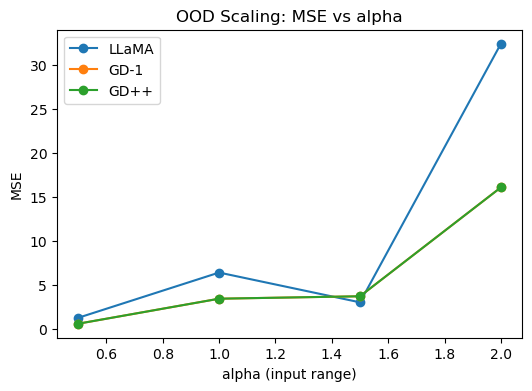

In [23]:

alphas = [0.5, 1.0, 1.5, 2.0]
alpha_results = []
for a in alphas:
    res_a = eval_linear_suite(
        n_tasks=10, d=10, N=10, alpha=a,
        eta_gd=tune["eta"], use_gdpp=True, gamma=tune["gamma"],
        temperature=0.0, do_sensitivity=False
    )
    res_a["alpha"] = a
    alpha_results.append(res_a)

plt.figure(figsize=(6,4))
plt.plot(alphas, [r["MSE_llama"] for r in alpha_results], marker="o", label="LLaMA")
plt.plot(alphas, [r["MSE_gd1"] for r in alpha_results], marker="o", label="GD-1")
plt.plot(alphas, [r["MSE_gdpp"] for r in alpha_results], marker="o", label="GD++")
plt.xlabel("alpha (input range)")
plt.ylabel("MSE")
plt.title("OOD Scaling: MSE vs alpha")
plt.legend()
plt.show()



## 7.Nonlinear sine tasks (Expected to show large error)
We can also test whether the model behaves sensibly on smooth nonlinear targets.


In [24]:

@dataclass
class SineTask:
    A: float
    B: float
    C: float
    X: np.ndarray      # (N, 1)
    y: np.ndarray      # (N, )
    x_test: float
    y_test: float

def sample_sine_task(N: int = 10, alpha: float = 1.0) -> SineTask:
    A = np.random.uniform(0.5, 1.5)
    B = np.random.uniform(0.5, 2.0)
    C = np.random.uniform(0.0, np.pi)
    X = np.random.uniform(-alpha, alpha, size=(N, 1))
    y = A * np.sin(B * X.reshape(-1) + C)
    x_test = float(np.random.uniform(-alpha, alpha))
    y_test = float(A * np.sin(B * x_test + C))
    return SineTask(A=A, B=B, C=C, X=X, y=y, x_test=x_test, y_test=y_test)

def build_prompt_sine(task: SineTask) -> str:
    lines = [f"({task.X[i,0]:.6f}) -> {task.y[i]:.6f}" for i in range(task.X.shape[0])]
    ctx = "\n".join(lines)
    prompt = (
        "You are solving a noiseless regression task where y is a smooth function of x.\n"
        "Given training pairs (x -> y), predict y for the query x_test.\n\n"
        + ctx + "\n\n"
        + f"x_test = {task.x_test:.6f}\n"
        + "Return only a single number (or JSON {\"y\": <number>})."
    )
    return prompt

def eval_sine_suite(n_tasks: int = 10, N: int = 10, alpha: float = 1.0, temperature: float = 0.0):
    gt_list, llama_list = [], []
    fails = 0
    for _ in range(n_tasks):
        t = sample_sine_task(N=N, alpha=alpha)
        p = build_prompt_sine(t)
        _, pred = llama_predict(p, temperature=temperature)
        if pred is None or not np.isfinite(pred):
            fails += 1
            continue
        gt_list.append(t.y_test); llama_list.append(pred)
    return {
        "MSE_llama": mse(llama_list, gt_list) if llama_list else float("nan"),
        "failures": fails,
        "evaluated": len(gt_list)
    }

sine_res = eval_sine_suite(n_tasks=10, N=10, alpha=1.0, temperature=0.0)
print("Sine task results:", sine_res)


Sine task results: {'MSE_llama': 499287.75745792844, 'failures': 0, 'evaluated': 10}
